In [1]:
from json.decoder import NaN
from math import nan

import math
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

In [3]:
country_data=pd.read_csv('country_with_data.csv')
df= country_data
df.set_index('Country',inplace=True)

In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 192 entries, Afghanistan to Zimbabwe
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ISO2                                191 non-null    str    
 1   Continent                           192 non-null    str    
 2   flag_url                            190 non-null    str    
 3   gdp                                 185 non-null    float64
 4   sex_ratio                           185 non-null    float64
 5   surface_area                        184 non-null    float64
 6   life_expectancy_male                181 non-null    float64
 7   unemployment                        179 non-null    float64
 8   homicide_rate                       167 non-null    float64
 9   urban_population_growth             185 non-null    float64
 10  secondary_school_enrollment_female  173 non-null    float64
 11  employment_agriculture              176 non-nu

In [5]:
df.keys()


Index(['ISO2', 'Continent', 'flag_url', 'gdp', 'sex_ratio', 'surface_area',
       'life_expectancy_male', 'unemployment', 'homicide_rate',
       'urban_population_growth', 'secondary_school_enrollment_female',
       'employment_agriculture', 'co2_emissions', 'forested_area', 'tourists',
       'life_expectancy_female', 'post_secondary_enrollment_female',
       'post_secondary_enrollment_male', 'primary_school_enrollment_female',
       'infant_mortality', 'gdp_growth', 'population', 'urban_population',
       'secondary_school_enrollment_male', 'pop_growth', 'region',
       'pop_density', 'internet_users', 'gdp_per_capita', 'fertility',
       'refugees', 'primary_school_enrollment_male'],
      dtype='str')

Country
Afghanistan    0.002708
Albania        0.036032
Algeria        0.002328
Andorra        1.328571
Angola         0.002979
                 ...   
Venezuela      0.003404
Vietnam        0.001024
Yemen          0.003403
Zambia         0.005336
Zimbabwe       0.006143
Name: rel, Length: 185, dtype: float64


np.float64(97.9)

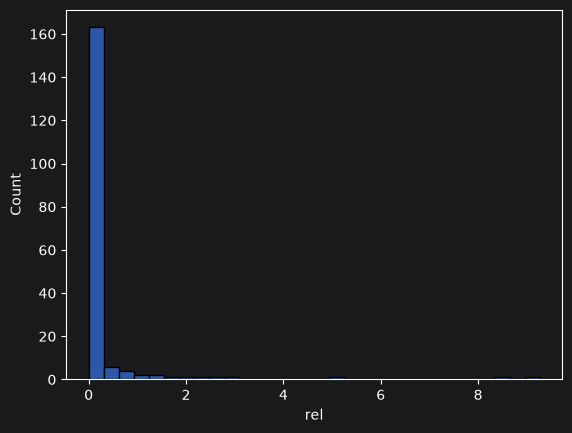

In [6]:
df['rel']=df['sex_ratio']/df['population']
ax=sns.histplot(df['rel'].dropna() , bins = 30)
print(df['rel'].dropna())
df.loc['Angola','sex_ratio']


In [81]:
df['urban_population']

Country
Afghanistan    25.8
Albania        61.2
Algeria        73.2
Andorra        88.0
Angola         66.2
               ... 
Venezuela      88.2
Vietnam        36.6
Yemen          37.3
Zambia         44.1
Zimbabwe       32.2
Name: urban_population, Length: 192, dtype: float64

In [92]:
df.loc['United States']

ISO2                                                                                 US
Continent                                                                 North America
flag_url                              https://api-ninjas-data.s3.us-west-2.amazonaws...
gdp                                                                          20580223.0
sex_ratio                                                                          97.9
surface_area                                                                  9833517.0
life_expectancy_male                                                               76.3
unemployment                                                                        3.9
homicide_rate                                                                       5.0
urban_population_growth                                                             0.9
secondary_school_enrollment_female                                                 98.7
employment_agriculture          

ISO2                                                                                 IL
Continent                                                                          Asia
flag_url                              https://api-ninjas-data.s3.us-west-2.amazonaws...
gdp                                                                            370588.0
sex_ratio                                                                          99.1
surface_area                                                                    22072.0
life_expectancy_male                                                               81.0
unemployment                                                                        3.8
homicide_rate                                                                       1.5
urban_population_growth                                                             1.7
secondary_school_enrollment_female                                                106.0
employment_agriculture          

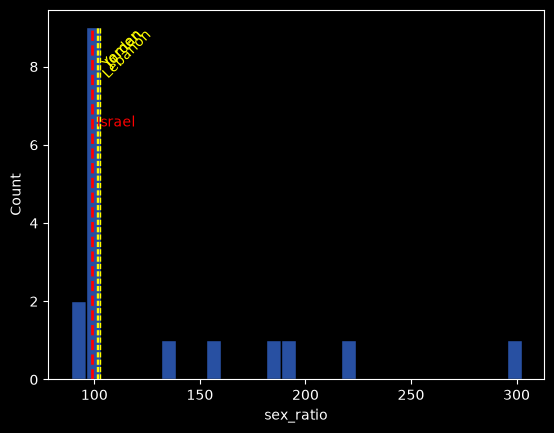

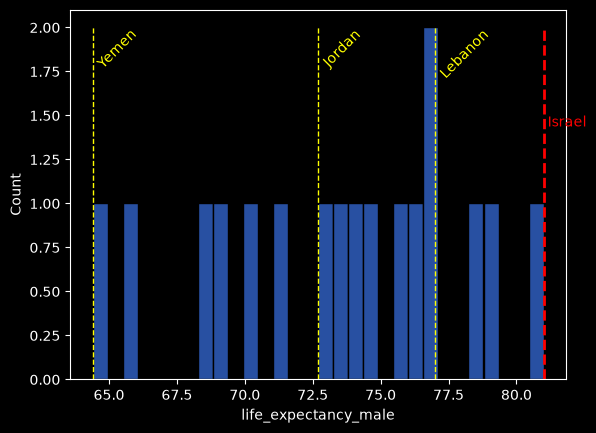

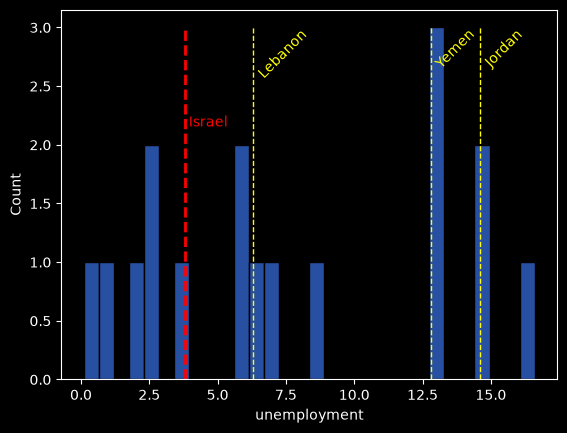

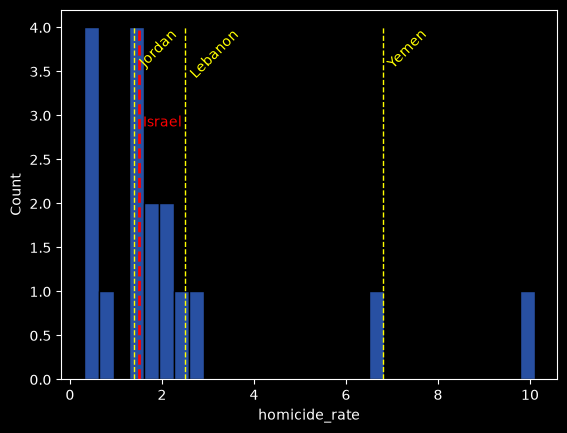

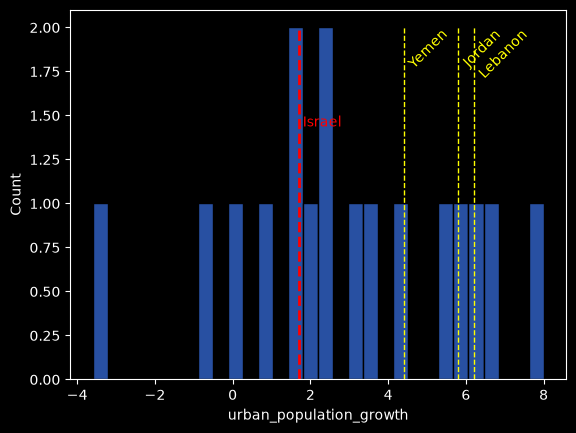

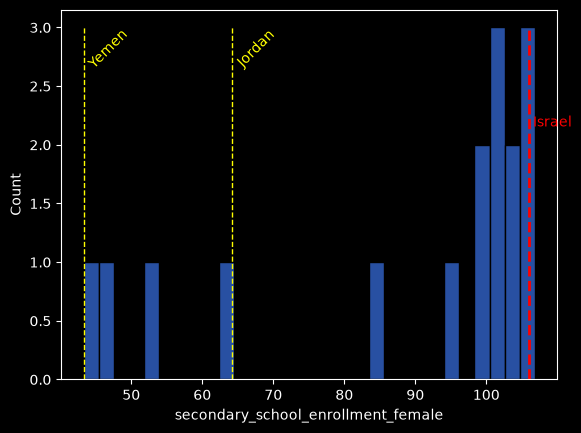

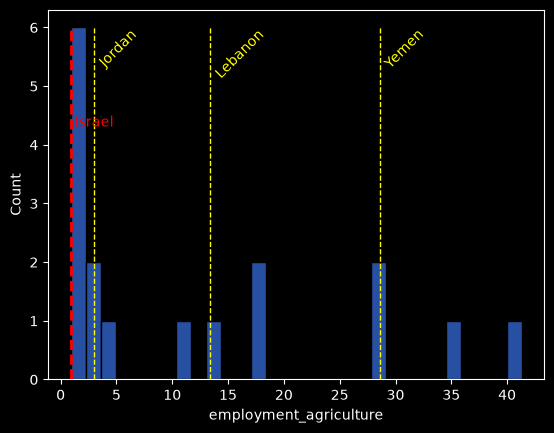

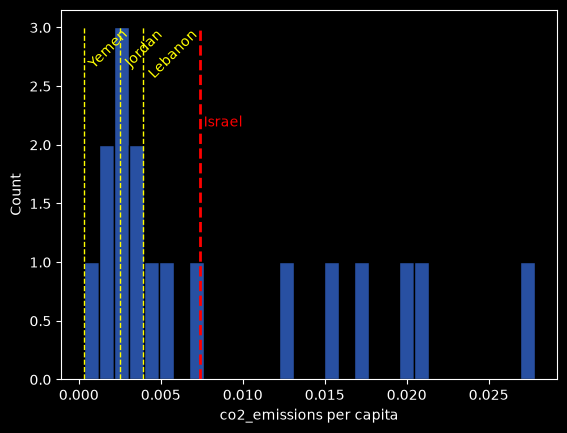

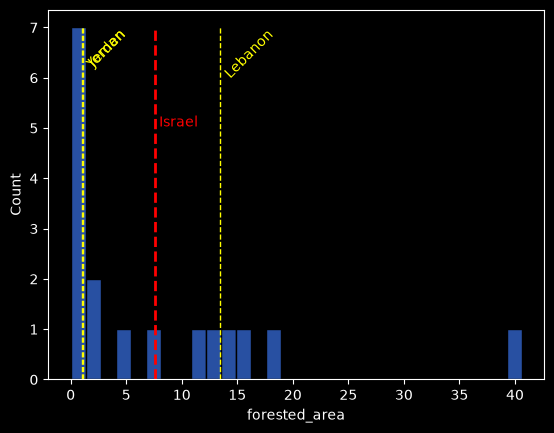

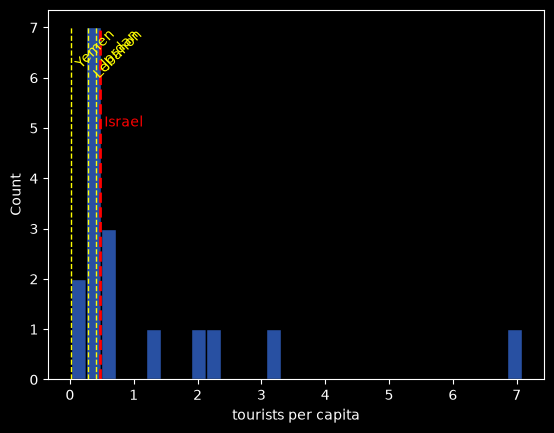

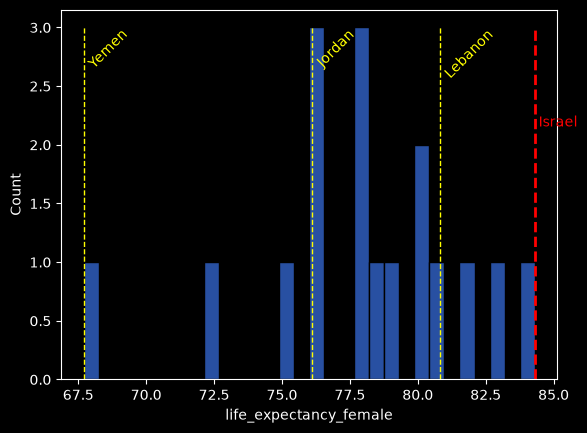

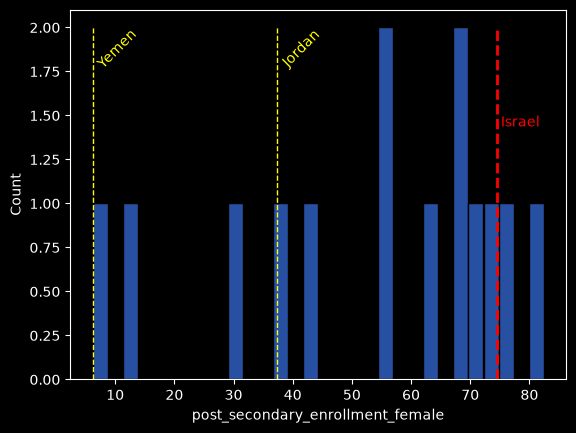

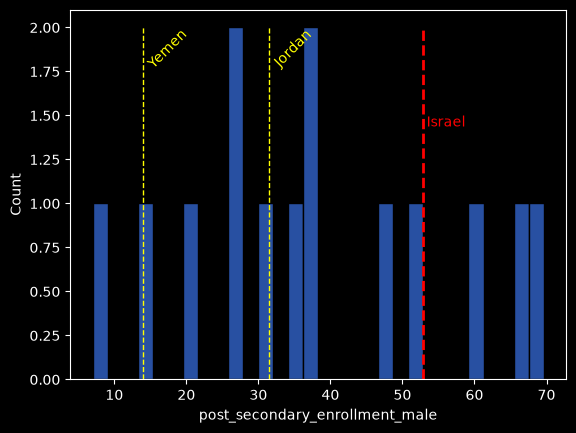

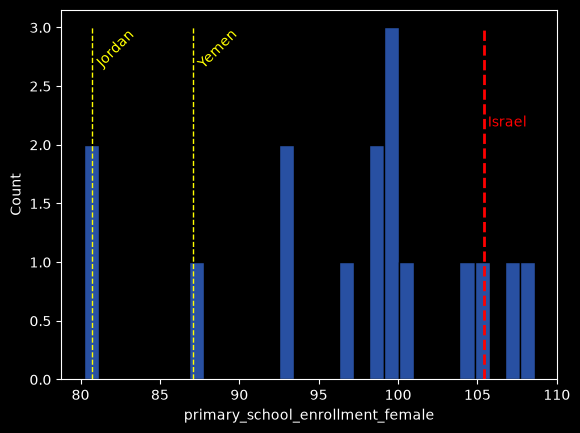

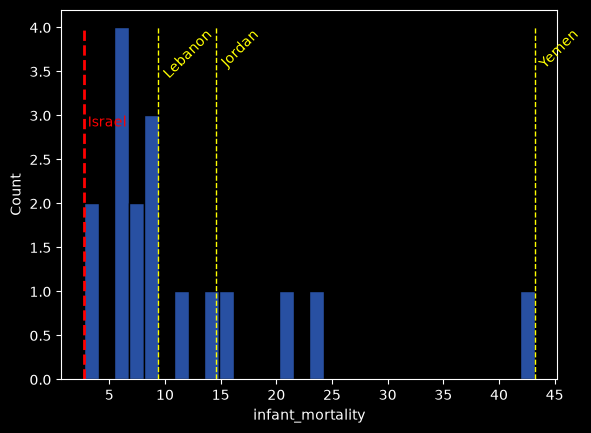

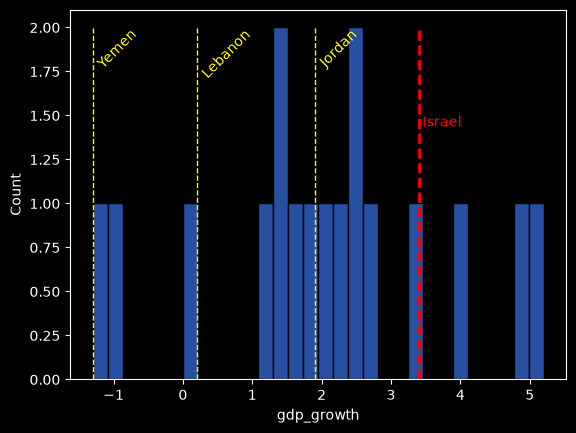

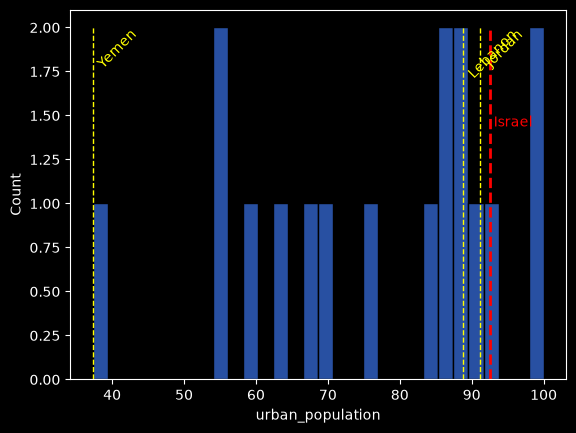

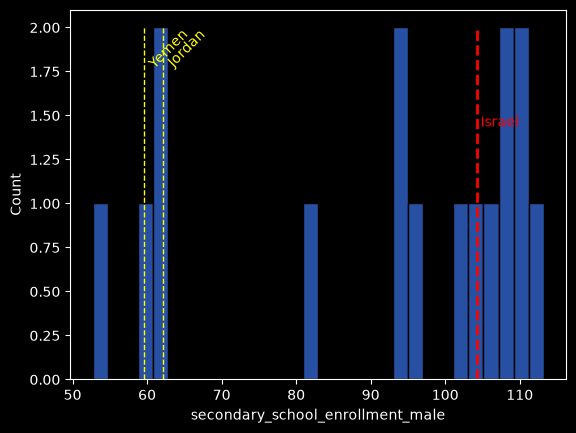

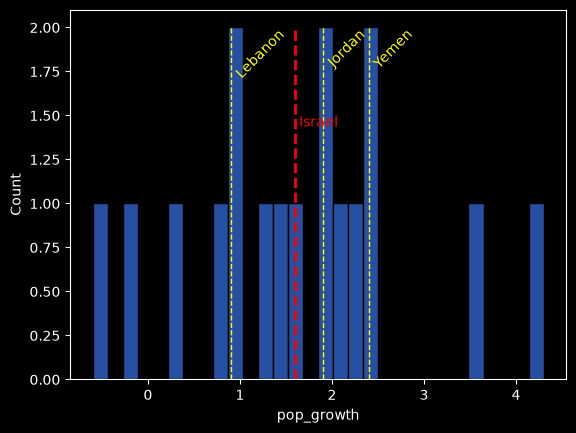

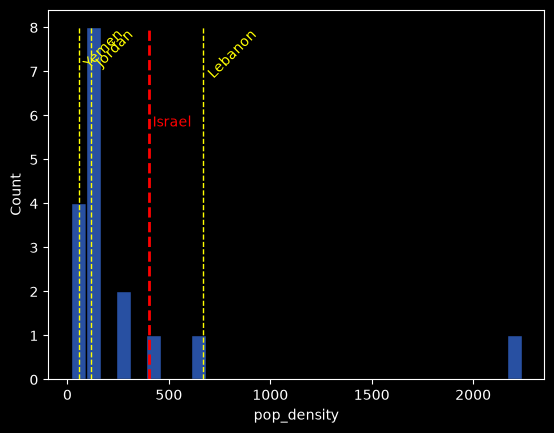

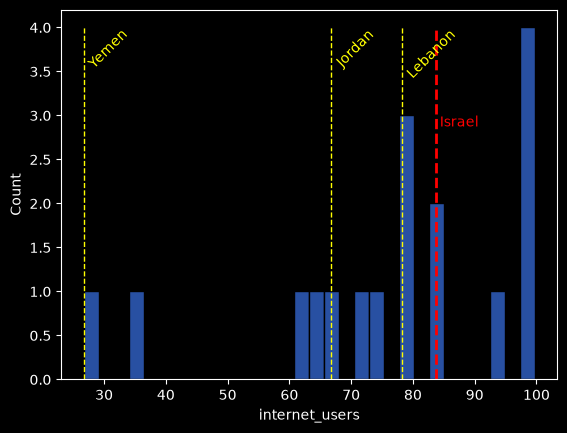

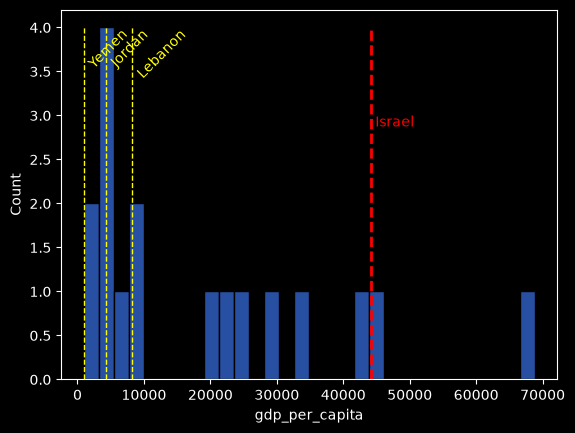

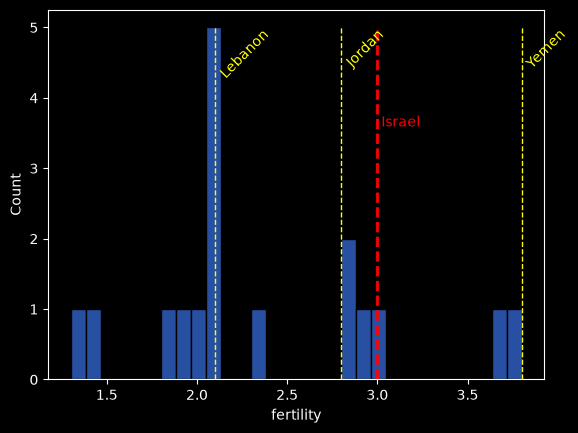

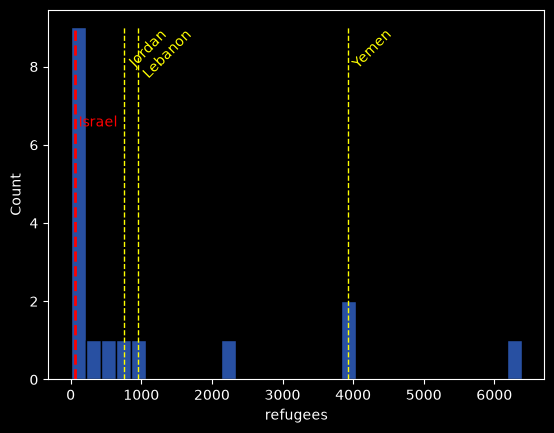

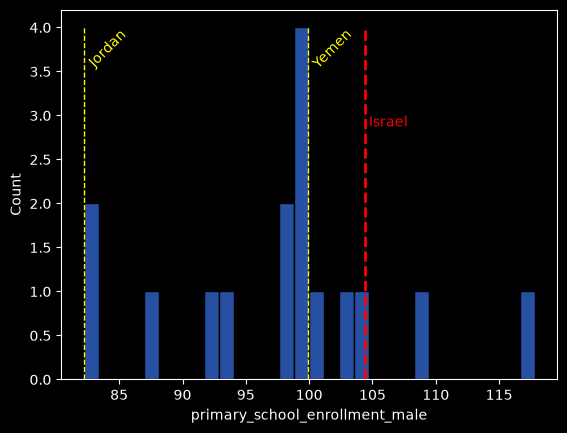

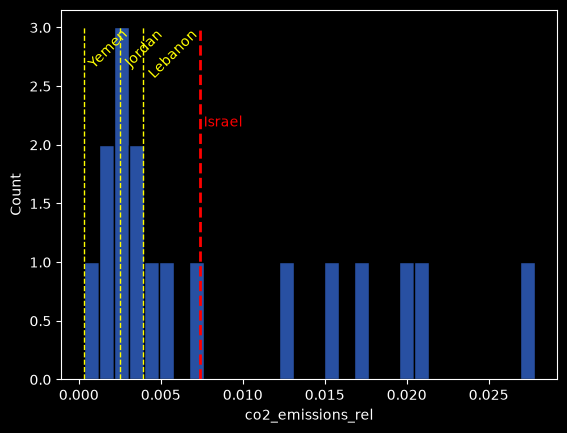

In [106]:
MyCountry = "Israel"
print (df.loc[MyCountry])
MyContinent = country_data.loc[MyCountry,'Continent']
MyRegion = country_data.loc[MyCountry,'region']
exclude_col = ["gdp","rel","population","surface_area"]


compareTo = 'Region'
if compareTo == 'World':
    df=country_data
    countries_of_interest = ['United States','China','Germany']
elif compareTo == 'Continent':
    df = country_data[country_data['Continent']==MyContinent]
    countries_of_interest = ['Japan','India','Iran']
elif compareTo == 'Region':
    df = country_data[country_data['region']==MyRegion]
    countries_of_interest = ['Lebanon','Jordan','Yemen']

DivideByPop = ['tourists','area','co2_emissions']
for col in df.keys():
    if col not in exclude_col and isinstance(df.loc[MyCountry,col],float):
        df['rel']=df[col]
        lb = col
        if col in DivideByPop:
            df['rel']= df['rel']/df['population']
            lb = lb + ' per capita'

        ax=sns.histplot(df['rel'].dropna() , bins = 30)

        plt.xlabel(lb)
        if df.loc[MyCountry,'rel']:
            max_count = max([bar.get_height() for bar in ax.containers[0]])
            plt.vlines(x=df.loc[MyCountry,'rel'], ymin=0, ymax=max_count, colors="red", linestyles="dashed", lw=2)
            plt.text(x=df.loc[MyCountry,'rel'], y=max_count * 0.75, s=f" {MyCountry}", color="red", rotation=0, va='top')
            for countryOfInterest in countries_of_interest:
                plt.vlines(x=df.loc[countryOfInterest,'rel'], ymin=0, ymax=max_count, colors="yellow", linestyles="dashed", lw=1)
                plt.text(x=df.loc[countryOfInterest,'rel'], y=max_count , s=f" {countryOfInterest}",  color="yellow", rotation=45, va='top')
            # Show the plot
            plt.show()

This section is comparison by continent/region

In [107]:
df.columns

Index(['ISO2', 'Continent', 'flag_url', 'gdp', 'sex_ratio', 'surface_area',
       'life_expectancy_male', 'unemployment', 'homicide_rate',
       'urban_population_growth', 'secondary_school_enrollment_female',
       'employment_agriculture', 'co2_emissions', 'forested_area', 'tourists',
       'life_expectancy_female', 'post_secondary_enrollment_female',
       'post_secondary_enrollment_male', 'primary_school_enrollment_female',
       'infant_mortality', 'gdp_growth', 'population', 'urban_population',
       'secondary_school_enrollment_male', 'pop_growth', 'region',
       'pop_density', 'internet_users', 'gdp_per_capita', 'fertility',
       'refugees', 'primary_school_enrollment_male', 'co2_emissions_rel',
       'rel'],
      dtype='str')

region
Eastern Europe     [Belarus, Bulgaria, Czechia, Hungary, Moldova,...
Northern Europe    [Denmark, Estonia, Finland, Iceland, Ireland, ...
Southern Europe    [Albania, Andorra, Bosnia and Herzegovina, Cro...
Western Europe     [Austria, Belgium, France, Germany, Liechtenst...
dtype: object


<Axes: xlabel='gdp_per_capita', ylabel='fertility'>

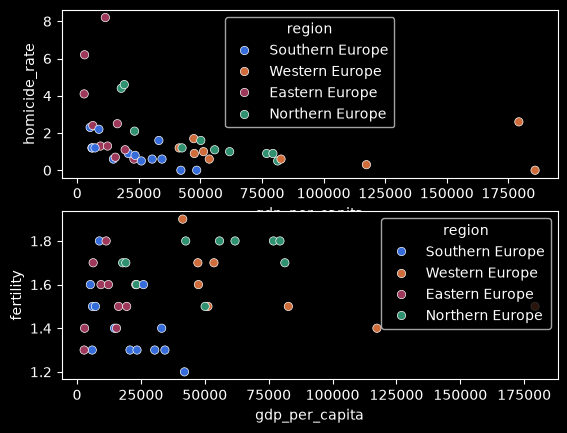

In [137]:
from matplotlib.pyplot import subplot

comparison = 'region'

if comparison=='Continent':
    df = country_data
else:
    Continent4RegionCompare= 'Europe'
    df = country_data[country_data['Continent']==Continent4RegionCompare]
    #regions = df['region'].unique_values()
    table = df.groupby('region').apply(lambda x: list(x.index))
    print(table)


subplot(2,1,1)
sns.scatterplot(data=df,x="gdp_per_capita",y="homicide_rate",hue=comparison)
subplot(2,1,2)
sns.scatterplot(data=df,x="gdp_per_capita",y="fertility",hue=comparison)



C:\Users\ruban\AppData\Local\Temp\ipykernel_24408\2137092557.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


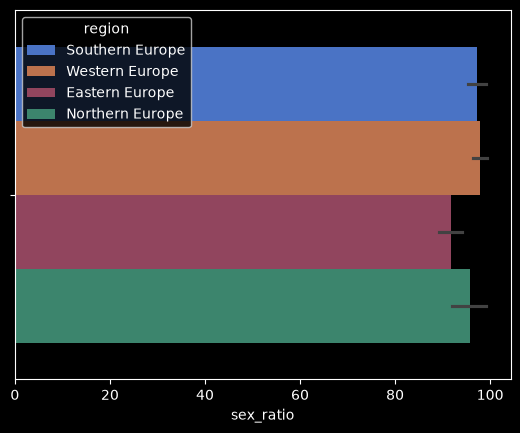

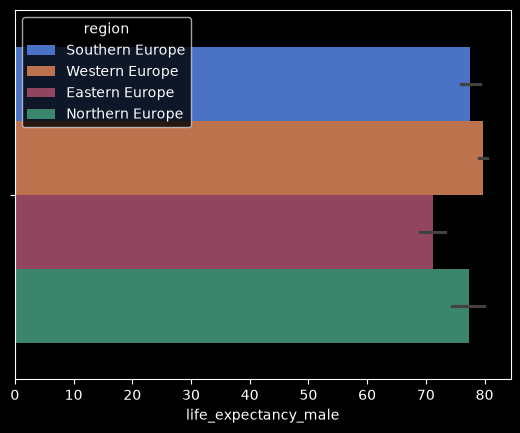

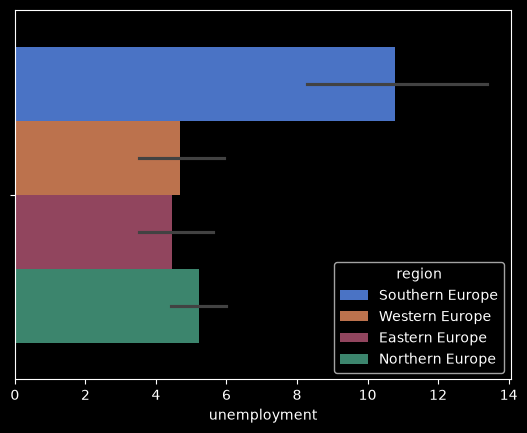

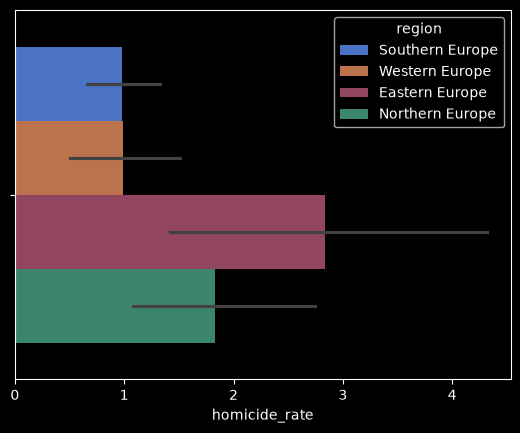

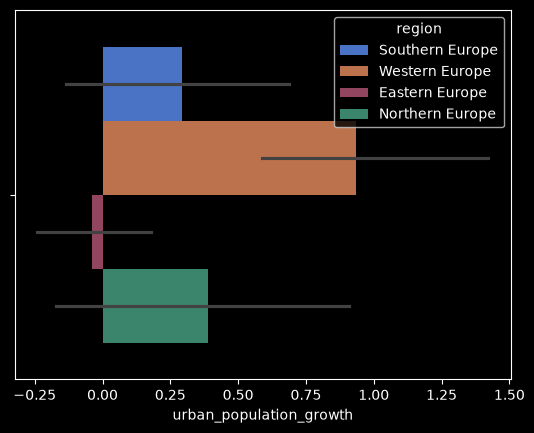

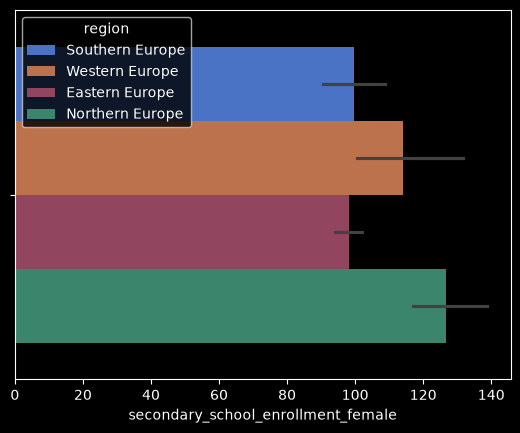

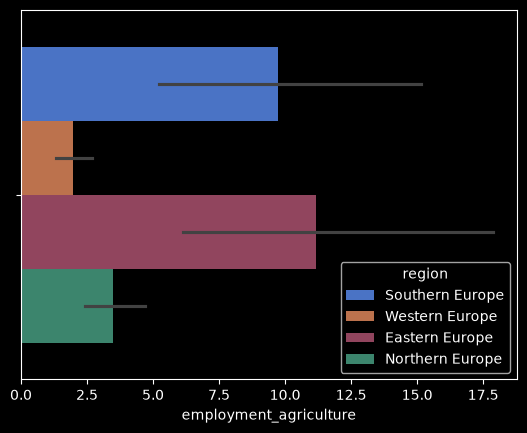

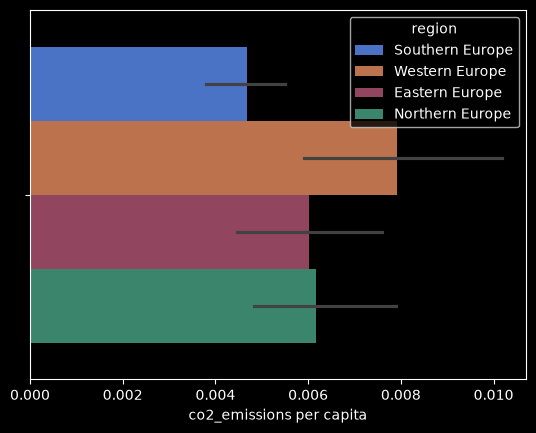

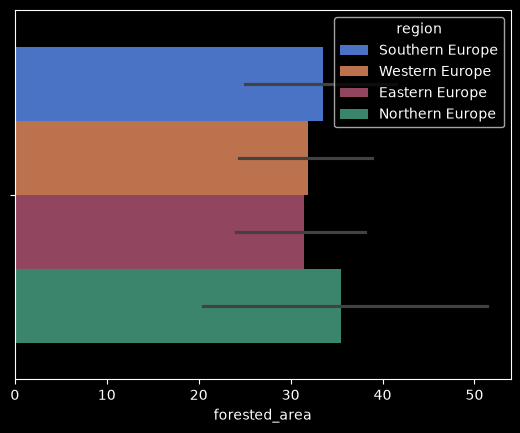

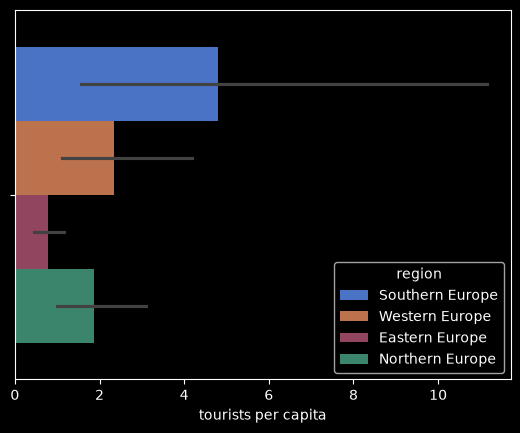

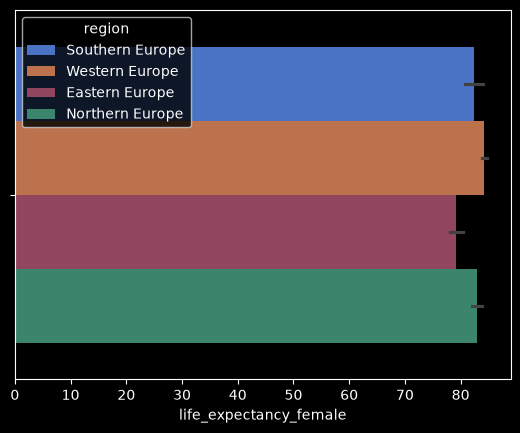

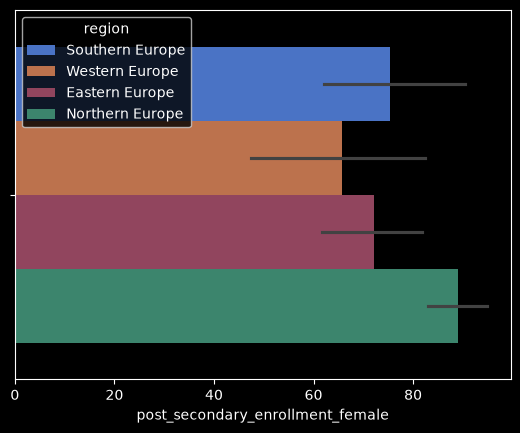

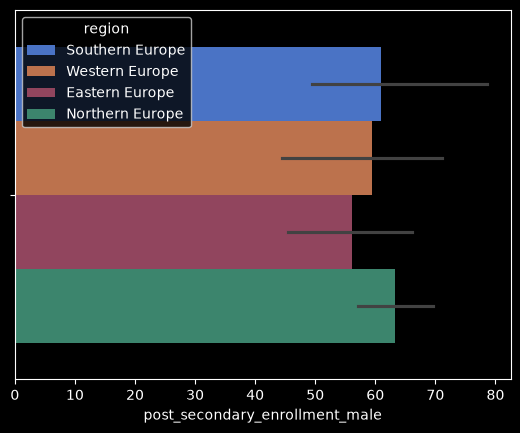

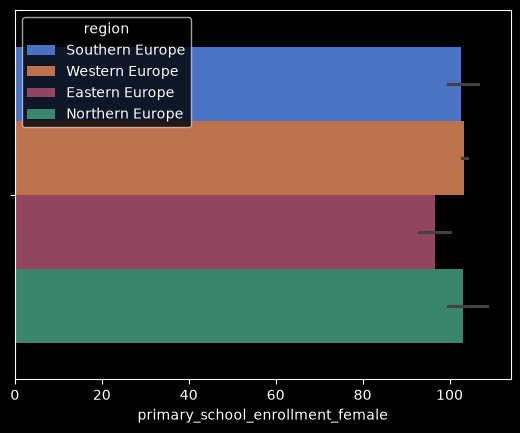

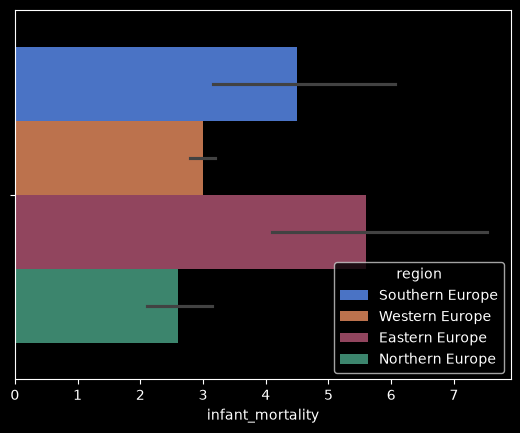

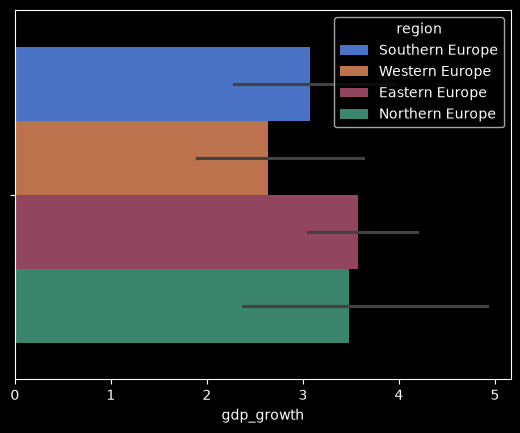

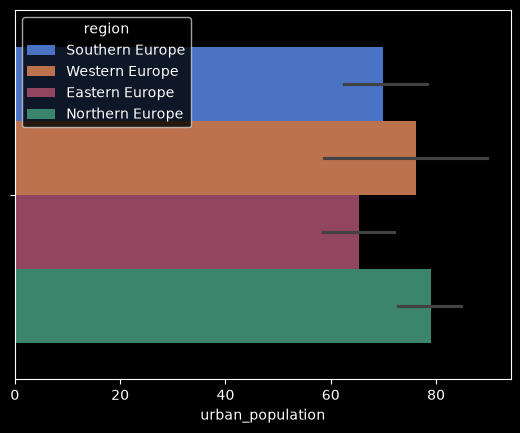

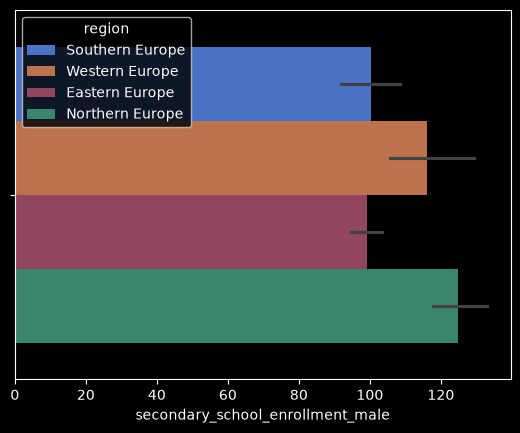

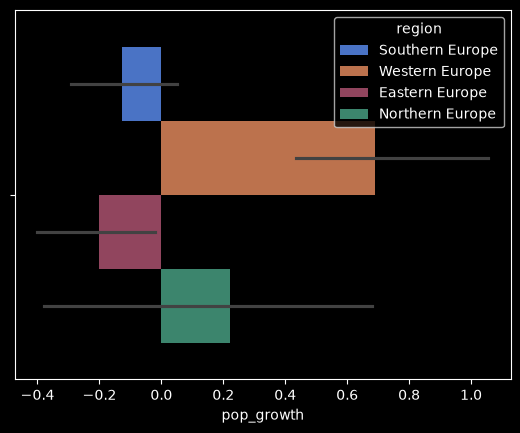

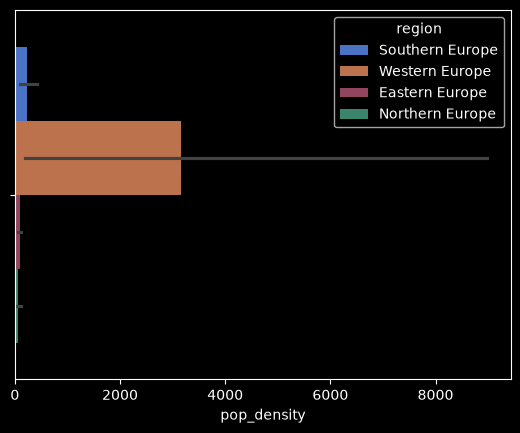

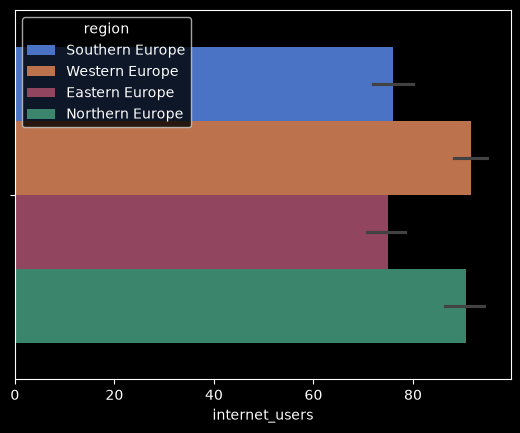

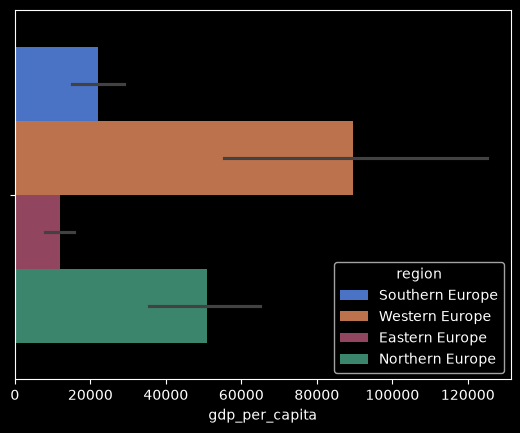

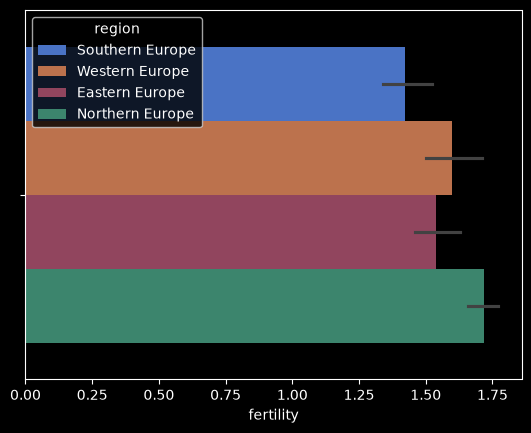

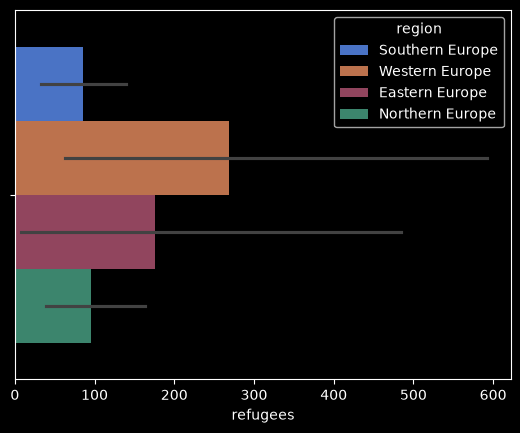

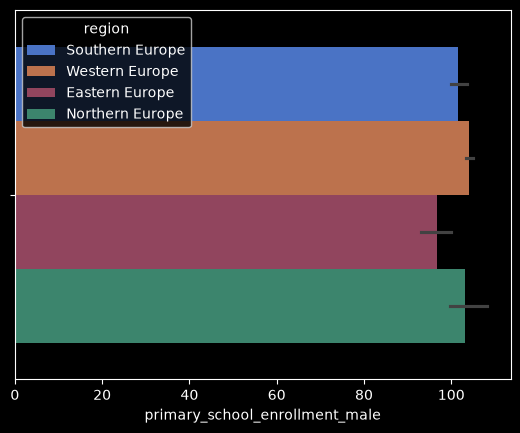

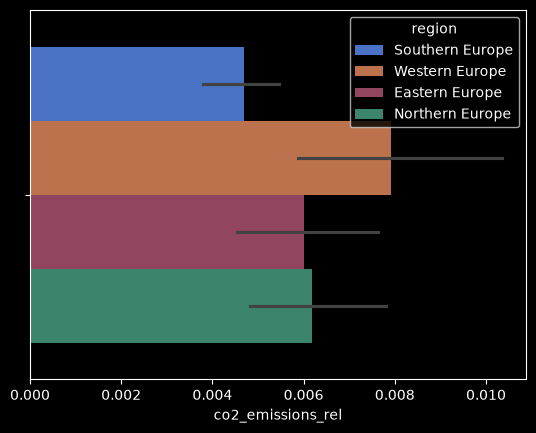

In [135]:
#sns.barplot(data=df, x="gdp_per_capita", hue=comparison)
exclude_col = ["gdp","rel","population","surface_area"]

DivideByPop = ['tourists','area','co2_emissions']
for col in df.keys():

    if col not in exclude_col and  isinstance(df.loc[df.index[0],col],float):
        plt.figure()
        lb = col
        if col in DivideByPop:
            df['rel']= df[col]/df['population']
            sns.barplot(data=df, x='rel',  hue=comparison)
            lb = lb + ' per capita'
            plt.xlabel(lb)
        else:
            sns.barplot(data=df, x=col,  hue=comparison)

In [134]:
df.index[0]


'Albania'